In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from multiprocessing import Pool
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures

plt.rcParams['text.latex.preamble'] = r"\usepackage{amsmath}"
plt.rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
plt.rc('text',usetex=True)

import julia
from julia import Main
from julia import Distributed
Main.eval("using QuadGK")

In [114]:
Main.include("..\\strong coupling\\constants.jl")
Main.include("..\\strong coupling\\alpha_s.jl")
Main.include("..\\splitting\\moments.jl")
Main.include("..\\hard\\hard.jl")
Main.include("..\\jet\\jet.jl")
Main.include("..\\cross section.jl")

Main.include("..\\fixed order\\analytic.jl")
Main.include("..\\fixed order\\perturbative EEC.jl")
Main.include("..\\fixed order\\SCET.jl")
Main.include("..\\fixed order\\non-singular.jl")

Main.include("..\\cross section.jl")
Main.include("..\\diff eqn.jl")
Main.include("..\\NP.jl")

In [115]:
zlist = np.exp(np.linspace(np.log(0.00001),np.log(0.2),100))

EEC_LL_bspace = []
EEC_NLL_bspace = []
EEC_NNLL_bspace = []

nf = 5
Q=91.2
params=[2.0]

for z in zlist:
    LL_bspace = Main.sigma_z(z=z, Q=Q, μ_ini=91.2, αs_ini=0.118, order=0, nf=5, params=params)
    NLL_bspace = Main.sigma_z(z=z, Q=Q, μ_ini=91.2, αs_ini=0.118, order=1, nf=5, params=params)
    NNLL_bspace = Main.sigma_z(z=z, Q=Q, μ_ini=91.2, αs_ini=0.118, order=2, nf=5, params=params)    

    EEC_LL_bspace.append(LL_bspace*z) 
    EEC_NLL_bspace.append(NLL_bspace*z)
    EEC_NNLL_bspace.append(NNLL_bspace*z)

In [116]:
import csv

row = [EEC_NNLL_bspace]

with open("convergence.csv", mode="a", newline="") as file:
    writer = csv.writer(file)
    writer.writerows(row)

In [118]:
import pandas as pd
df = pd.read_csv("convergence.csv", header=None)
dict={}
for i in range(8):
    dict[9-i]=np.array(df.iloc[i])
print(dict[9])

[0.00172124 0.00189849 0.00209356 0.00230816 0.00254411 0.00280341
 0.0030882  0.00340081 0.0037437  0.00411952 0.0045311  0.00498144
 0.00547369 0.00601118 0.00659738 0.0072359  0.00793043 0.00868476
 0.00950271 0.01038809 0.01134464 0.012376   0.01348557 0.01467651
 0.01595159 0.01731311 0.01876283 0.02030184 0.02193044 0.02364809
 0.02545329 0.0273435  0.02931506 0.03136315 0.03348177 0.0356637
 0.03790051 0.04018262 0.04249931 0.04483883 0.0471885  0.0495348
 0.05186356 0.05416008 0.05640934 0.05859619 0.0607056  0.06272287
 0.06463389 0.06642539 0.06808523 0.06960259 0.07096826 0.07217481
 0.07321674 0.07409064 0.0747952  0.07533123 0.07570161 0.07591113
 0.07596636 0.07587536 0.07564746 0.07529294 0.07482278 0.0742483
 0.07358094 0.07283198 0.07201237 0.07113252 0.0702022  0.06923044
 0.0682255  0.06719485 0.0661452  0.06508248 0.06401197 0.06293825
 0.06186534 0.06079672 0.05973539 0.05868392 0.05764449 0.05661895
 0.05560883 0.05461542 0.05363974 0.05268263 0.05174473 0.0508265

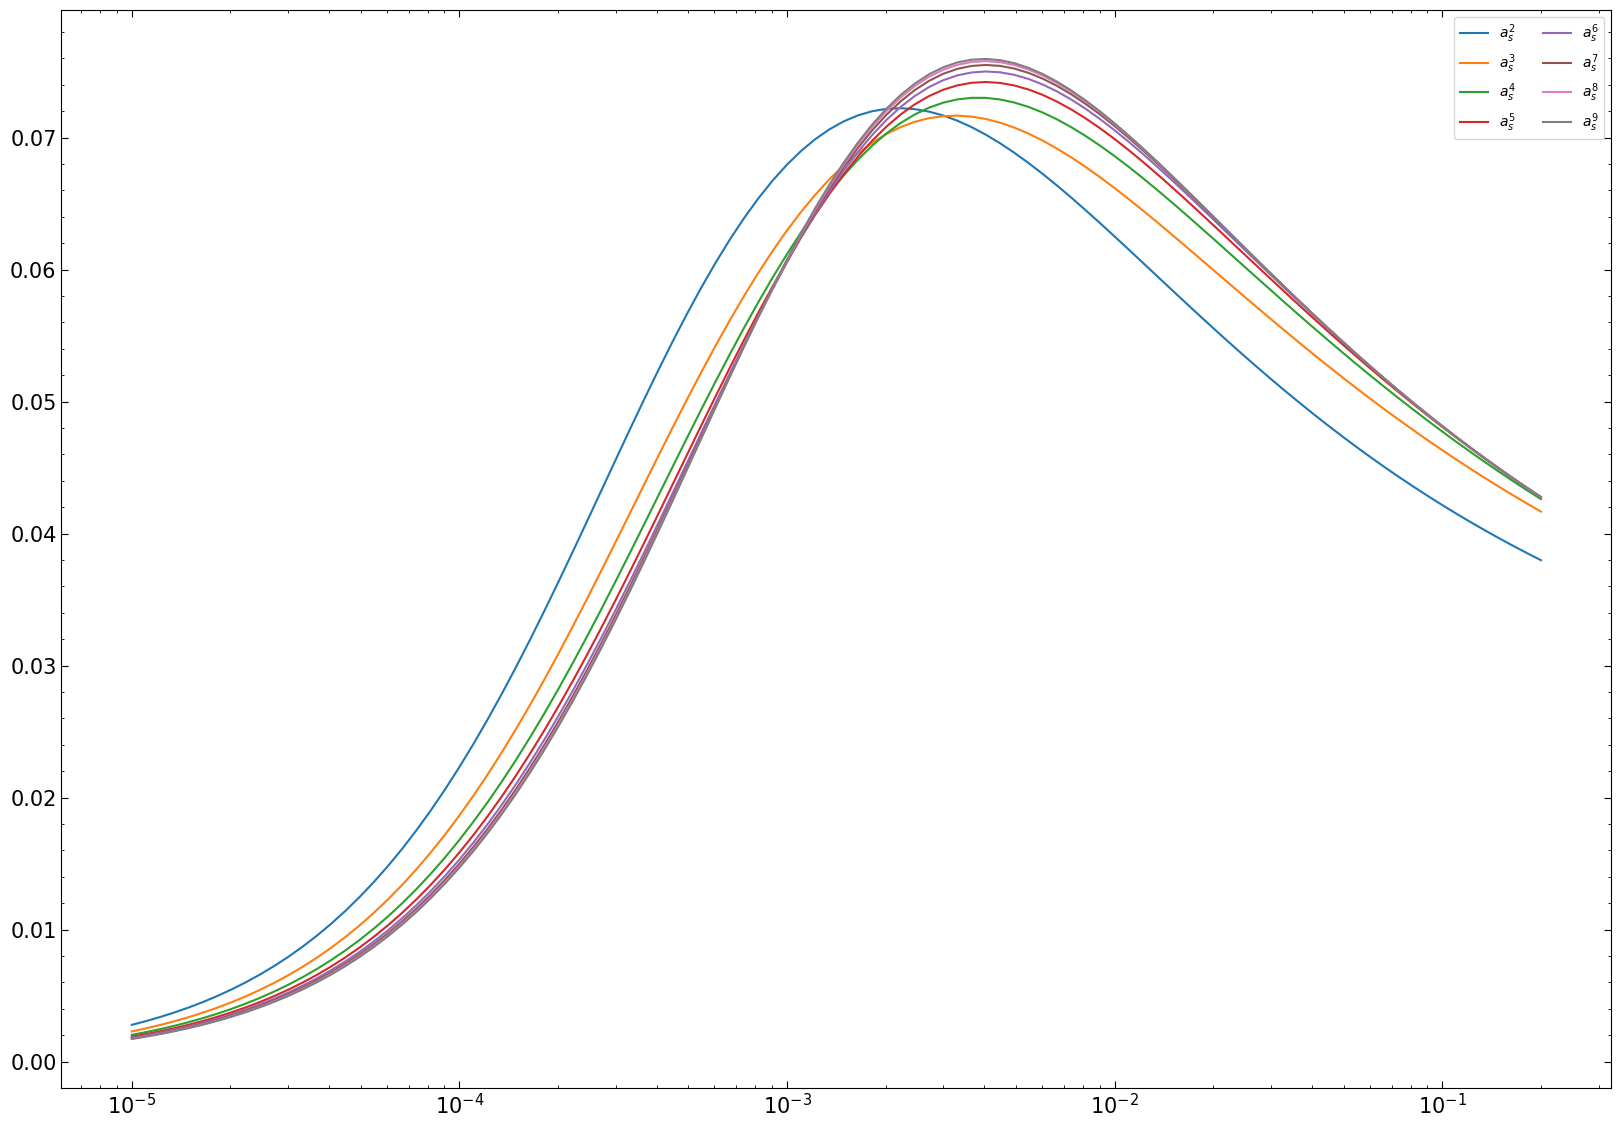

In [119]:
plt.figure(figsize=(20, 14))

sizeOfTick = 15
plt.minorticks_on()
plt.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
plt.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)

#plt.xlim(0.1,0.2)
#plt.ylim(0.01,0.06)
plt.xticks([0,0.05,0.1,0.15,0.2])
#plt.yticks([0.01,0.02,0.03,0.04,0.05,0.06])
plt.xscale('log')


#plt.plot(zlist, EEC_LL_bspace, label="LL bspace")
#plt.plot(zlist, EEC_NLL_bspace, label="NLL bspace")

for i in range(2,10):
    name = f"$a_s^{i}$"
    plt.plot(zlist, dict[i], label=name)

plt.legend(ncol=2)
plt.show()

In [25]:
import pandas as pd
import numpy as np

χ_lower = 1.0
χ_upper = 60.0

#-------------------------------------------------------------------
#dataset_names = ["OPAL"]
#-------------------------------------------------------------------
#-------------------------------------------------------------------
dataset_names = ["OPAL","SLD","TOPAZ_595","TOPAZ_533",
                 "TASSO_435","TASSO_348","MARKII","MAC"]
#-------------------------------------------------------------------

dataset_qua = ["OPAL","MAC"]  
 
df_qua = {}

for name in dataset_qua:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = df["STAT"]
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_qua[name] = df1

dataset_ss = ["SLD","DELPHI","TOPAZ_595","TOPAZ_533","TASSO_435","TASSO_348","MARKII"]

df_ss = {}

for name in dataset_ss:
    file_path = f"../data/{name}.csv"
    df = pd.read_csv(file_path)
    
    χ = df["CHI"]
    EEC = df["EEC"]
    ERROR = np.sqrt(df["STAT"]**2+df["SYS"]**2)
    
    df1 = pd.DataFrame({"CHI": χ, "EEC": EEC, "ERROR": ERROR})
    df_ss[name] = df1

df = df_qua
df.update(df_ss)

df_truncated = {}
χ_list = {}
EEC = {}
ERROR = {}

Q_list = {}
Q_list["SLD"]       = 91.2
Q_list["OPAL"]      = 91.2
#Q_list["OPAL"]      = 500.0
Q_list["DELPHI"]    = 91.2
Q_list["TOPAZ_595"] = 59.5
Q_list["TOPAZ_533"] = 53.3
Q_list["TASSO_435"] = 43.5
Q_list["TASSO_348"] = 34.8
Q_list["MARKII"]    = 29.0
Q_list["MAC"]       = 29.0

for name in dataset_names:
    df_truncated[name] = df[name][(df[name]["CHI"] <= χ_upper) & (df[name]["CHI"] >= χ_lower)]

    χ_list[name] = np.array(df_truncated[name]["CHI"])
    EEC[name] = np.array(df_truncated[name]["EEC"])
    ERROR[name] = np.array(df_truncated[name]["ERROR"])

In [30]:
χlist = np.linspace(χ_lower,χ_upper)/180*np.pi 

EEC_LO = []
EEC_NLO = []
EEC_LL_matched = []
EEC_NLL_matched = []
EEC_NNLL_matched = []

for χ in χlist:
    LL = Main.sigma_χ(χ=χ, Q=91.2, 
                    μ_ini=91.2, αs_ini=0.118, order=0, nf=5)
    NLL = Main.sigma_χ(χ=χ, Q=91.2, 
                    μ_ini=91.2, αs_ini=0.118, order=1, nf=5)
    NNLL = Main.sigma_χ(χ=χ, Q=91.2, 
                    μ_ini=91.2, αs_ini=0.118, order=2, nf=5)

    LO = Main.perturbation_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=1)
    NLO = Main.perturbation_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=2)
    non_singular_0 = Main.non_singular_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=0)
    non_singular_1 = Main.non_singular_sigma_χ(Q=91.2, χ=χ, μ_ini=91.2, αs_ini=0.118, nf=5, order=1)

    EEC_LO.append(LO)
    EEC_NLO.append(NLO)
    EEC_LL_matched.append(LL+non_singular_0) 
    EEC_NLL_matched.append(NLL+non_singular_1)
    EEC_NNLL_matched.append(NNLL+non_singular_1)    

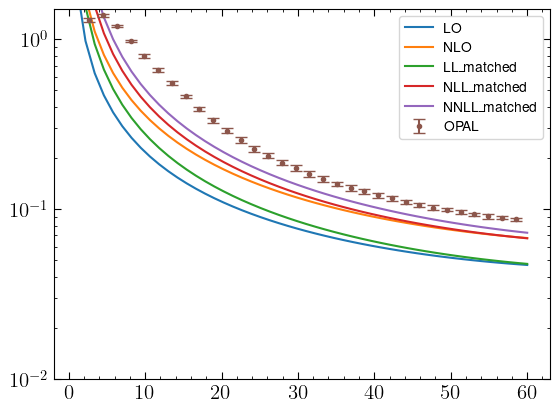

In [33]:
sizeOfTick = 15
plt.minorticks_on()
plt.tick_params(axis="both",direction="in", length=5,labelsize = sizeOfTick, top=True, right=True)
plt.tick_params(axis="both",which = "minor",direction="in", length=2.5,labelsize = sizeOfTick, top=True, right=True)

#plt.xlim(0,0.2)
plt.ylim(0.01,1.5)
#plt.xticks([0,0.05,0.1,0.15,0.2])
#plt.yticks([0.01,0.02,0.03])
plt.plot(χlist*180/np.pi, EEC_LO, label="LO")
plt.plot(χlist*180/np.pi, EEC_NLO, label="NLO")
plt.plot(χlist*180/np.pi, EEC_LL_matched, label="LL_matched")
plt.plot(χlist*180/np.pi, EEC_NLL_matched, label="NLL_matched")
plt.plot(χlist*180/np.pi, EEC_NNLL_matched, label="NNLL_matched")
plt.errorbar(χ_list["OPAL"], EEC["OPAL"], ERROR["OPAL"], label="OPAL", fmt='o', capsize=4,markersize=3)
#plt.plot(zlist, simplified, label="simp")
plt.yscale('log')
plt.legend()